In [1]:
# WORK IN PROGRESS

A more complex example
======================

Here, we are going to learn how to use *pyKasso* with a little more complex example than the [example_01_quick_introduction.ipynb](example_01_quick_introduction.ipynb).

This example is intended to show more specifics functionalities and to understand how python loops can be used to perform several simulations.

Here, we are going to use the datafiles from the Betteraz's catchment.

Create a new project
--------------------

First, we need to import the pyKasso module:

In [2]:
import pykasso as pk

Betteraz's datafiles are already integrated in the *pyKasso* module. <br>
With the ``get_settings()`` function, the module create a copy of the default settings file on the directory where the script is executed. <br>
If the ``example`` argument is ``True``, the function will provide us all the settings file from the Betteraz's catchment.  

In [3]:
#pk.get_settings(example=True)

The function created a directory named ``inputs``. Inside, we can find all the settings files required to reproduce the Betteraz's catchment. <br>

We can now create an instance of the ``SKS`` class and give the relative path of a settings file.

In [4]:
betteraz = pk.SKS('inputs/test.yaml')

Visualize the generated environment
-------------------------------------
	
Let's have a look on the geological settings:

In [5]:
#for data in ["geology", "faults", "fractures", "topography", "orientationx", "orientationy"]:
#    betteraz.show_catchment(data=data)

We can also visualize the data cut with the polygon delimitations:

In [6]:
#for data in ["geology", "faults", "fractures", "topography", "orientationx", "orientationy"]:
    #betteraz.show_catchment(data=data, mask=True)

Compute karst network and tweak parameters
------------------------------------------

We can simulate different karst network by changing some parameters. There is a ``get`` and a ``set`` method for almost each parameter.


 This network contains  1  connected components

Computing:
 - mean length,cv length,length entropy,mean tortuosity
 - orientation entropy,aspl,cpd,md,cv degree,cvd
[1548.57001074 1531.06190116 1513.52133156 1496.02749792 1478.6458639
 1461.4202065  1444.36966797 1427.48697704 1410.73548242 1394.04602192
 1377.3192032  1360.44168249 1343.32031162 1325.92205771 1308.29318835
 1290.54159652 1272.79627742 1255.1715602  1237.75016333 1220.58238818
 1203.69291658 1187.08817264 1170.76028262 1154.6862003  1138.82289753
 1123.10259531 1107.43563917 1091.72947011 1075.92421117 1060.0287468
 1044.13218233 1028.38133642 1012.94132745  997.96346126  983.57104041
  969.85958592  956.90362262  944.76459579  933.49814442  923.16068836
  913.81386049  905.52099761  898.32509527  892.19593521  886.93635432
  882.05180633  876.71877202  870.37103724  863.63396268  857.65892556
  852.41413431  846.39648999  839.47522162  833.62124646  828.86905212
  822.53141931  814.89855872  809.78742055  807.9664124

C:\Users\kiwi\anaconda3\envs\pykasso\lib\site-packages\matplotlib\image.py:443: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
C:\Users\kiwi\anaconda3\envs\pykasso\lib\site-packages\matplotlib\image.py:444: UserWarning: Warning: converting a masked element to nan.
  vmid = np.float64(self.norm.vmin) + dv / 2


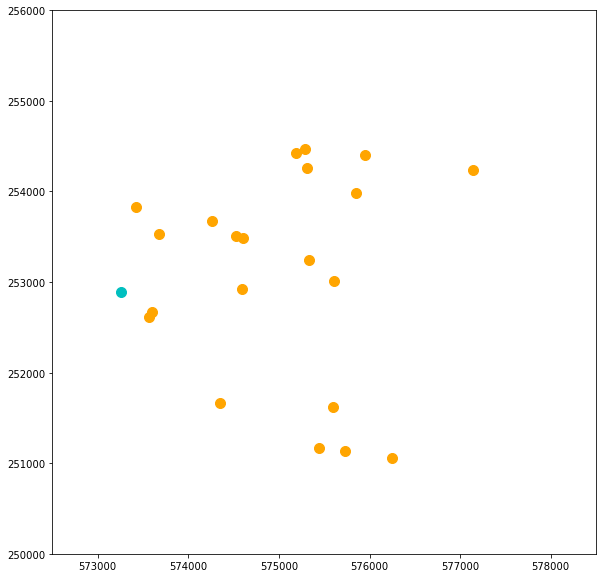

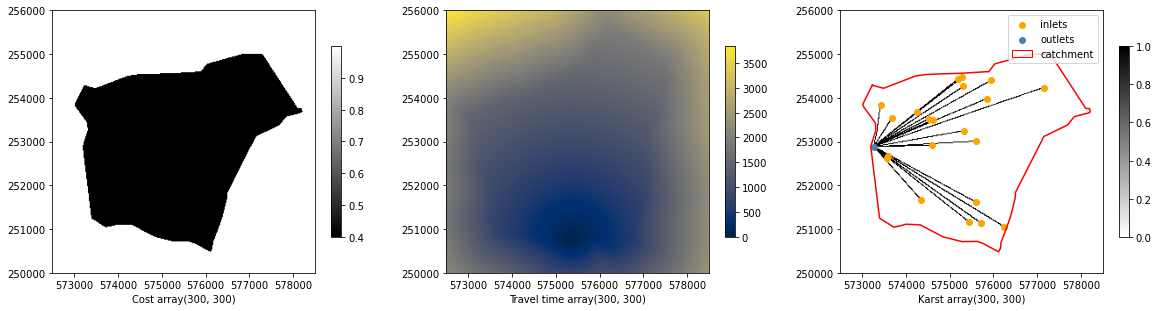

In [7]:
betteraz = pk.SKS('inputs/test.yaml')
betteraz.compute_karst_network()
betteraz.show()

Now, we can write a loop and change some parameters. For example, let's see the influence of the alpha parameter on the generated karstic networks:

In [8]:
"""
#betteraz = pk.SKS('inputs/test.yaml')
import numpy as np
alphas = [1.7,1.9]#,2.1,2.3,2.5]
nb_frac_fam = len(betteraz.settings['fractures_densities'])


for alpha in alphas:
    #betteraz.set_fractures_alpha(np.full((1, nb_frac_fam), alpha)[0])
    #betteraz.update_inlets()
    #betteraz.update_fractures() # will produce new fractures
    #betteraz.increment_rand_seed()
    #betteraz.shuffle_inlets()
    #betteraz.show_catchment(data='fractures', mask=1)
    #betteraz.update_all()
    betteraz.set_outlets_mode('random')
    betteraz.set_outlets_number(1)
    betteraz.set_inlets_mode('composite')
    betteraz.set_inlets_number(100)
    #betteraz.set_outlets_importance([1,1])
    betteraz.update_outlets()
    betteraz.update_inlets()
    betteraz.compute_karst_network()
    betteraz.show()
    
"""

"\n#betteraz = pk.SKS('inputs/test.yaml')\nimport numpy as np\nalphas = [1.7,1.9]#,2.1,2.3,2.5]\nnb_frac_fam = len(betteraz.settings['fractures_densities'])\n\n\nfor alpha in alphas:\n    #betteraz.set_fractures_alpha(np.full((1, nb_frac_fam), alpha)[0])\n    #betteraz.update_inlets()\n    #betteraz.update_fractures() # will produce new fractures\n    #betteraz.increment_rand_seed()\n    #betteraz.shuffle_inlets()\n    #betteraz.show_catchment(data='fractures', mask=1)\n    #betteraz.update_all()\n    betteraz.set_outlets_mode('random')\n    betteraz.set_outlets_number(1)\n    betteraz.set_inlets_mode('composite')\n    betteraz.set_inlets_number(100)\n    #betteraz.set_outlets_importance([1,1])\n    betteraz.update_outlets()\n    betteraz.update_inlets()\n    betteraz.compute_karst_network()\n    betteraz.show()\n    \n"

In [9]:
#betteraz.karst_simulations
"""
import agd
from agd import Eikonal
from agd.Metrics import Riemann

nx = 3
ny = 3
nz = 3

xmin=-0.5
xmax=2.5

ymin=-1
ymax=5

zmin=-1.5
zmax=7.5

riemannMetric = []                    #this changes at every iteration, but cannot be stored?
fastMarching = agd.Eikonal.dictIn({
'model'             : 'Isotropic2',      #set algorithm from settings file ('Isotropic2', 'Isotropic3', 'Riemann2', 'Riemann3')
'order'             : 2,               #recommended setting: 2 (replace by variable)
'exportValues'      : 1,               #export the travel time field
'exportGeodesicFlow': 1                #export the walker paths (i.e. the conduits)
})

print(fastMarching.keys)
help(fastMarching)

fastMarching.SetRect(                 #give the fast-marching algorithm the model grid
sides=[[ymin, ymax],
       [xmin, xmax],
       [zmin,zmax]],   
dims=[ny, nx, nz])

fastMarching.Axes()
fastMarching.Grid()
"""
from skimage import io
import matplotlib.pyplot as plt
import matplotlib

img = io.imread('../class/inputs/img/test.png')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
#ax = axes.ravel()

#images = data.stereo_motorcycle()
axes[0].imshow(img)


fig.tight_layout()
plt.show()
print(img.shape)

FileNotFoundError: No such file: 'C:\Users\kiwi\Desktop\pykasso\pyKasso\notebooks\class\inputs\img\test.png'

In [ ]:
#betteraz.karst_simulations[0].__dict__.keys()

In [ ]:
#betteraz.compare_stats()

In [ ]:
## Marche pas quand
# Grille 300*400
# y'a plusieurs outlets